In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.metrics import  accuracy_score, classification_report, confusion_matrix, f1_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from torch.utils.data import TensorDataset, DataLoader

In [2]:
df = pd.read_csv("undersampled_CIC2019_dataset.csv")

In [3]:
def generate_sample(df, n, rs):
    dos_set = df[df["label"].str.contains("DoS", case=False, na=False)]
    dos_sample = (dos_set.sample(n=n, random_state=rs, replace=False).reset_index(drop=True))
    dos_sample["label"] = "DoS_ATTACK"
    dos_sample["label"].value_counts()
    non_dos_set = df[(df["label"] != "BENIGN") & (~df["label"].str.contains("DoS", case=False, na=False))]
    non_dos_sample = (non_dos_set.sample(n=n, random_state=rs, replace=False).reset_index(drop=True))
    non_dos_sample["label"] = "NON_DoS_ATTACK"
    non_dos_sample["label"].value_counts()
    attack_sample =pd.concat([dos_sample, non_dos_sample]).reset_index(drop=True)
    attack_sample["label"].value_counts()
    benign_set = df[df["label"] == "BENIGN"]
    benign_sample = benign_set.sample(n=non_dos_sample.shape[0], replace=False, random_state=rs)
    return pd.concat([benign_sample, attack_sample]).reset_index(drop=True)

In [4]:
clean_sample = generate_sample(df, 50000, 42)
clean_sample.shape

(150000, 90)

In [5]:
clean_sample["label"].value_counts()

label
BENIGN            50000
DoS_ATTACK        50000
NON_DoS_ATTACK    50000
Name: count, dtype: int64

In [6]:
remaining = df.drop(clean_sample.index)
adv_sample = generate_sample(remaining, 50000, 42)

In [7]:
size = adv_sample.shape[0]
adv_sample.shape

(150000, 90)

In [8]:
adv_sample["label"].value_counts()

label
BENIGN            50000
DoS_ATTACK        50000
NON_DoS_ATTACK    50000
Name: count, dtype: int64

In [9]:
filename = "clean_sample_" + str(size) + ".csv"
clean_sample.to_csv(filename, index=False)
filename = "adv_sample_" + str(size) + ".csv"
adv_sample.to_csv(filename, index=False)

In [10]:
le = LabelEncoder()
adv_sample["label"] = le.fit_transform(adv_sample["label"])
X = adv_sample.drop(columns=["label"], errors="ignore").select_dtypes(include=[np.number])
X.replace([np.inf, -np.inf], np.nan, inplace=True)
X.fillna(0, inplace=True)
y = adv_sample["label"]
label_mapping = dict(zip(le.classes_, range(len(le.classes_))))
print(label_mapping)

{'BENIGN': 0, 'DoS_ATTACK': 1, 'NON_DoS_ATTACK': 2}


In [11]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y # 0.2
)

In [12]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)

In [13]:
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.long)
X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val.values, dtype=torch.long)
train_loader = DataLoader(TensorDataset(X_train_tensor, y_train_tensor), batch_size=2048, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val_tensor, y_val_tensor), batch_size=2048)

X_min_raw = X.min(axis=0).values
X_max_raw = X.max(axis=0).values
X_min_df = pd.DataFrame([X_min_raw], columns=X.columns)
X_max_df = pd.DataFrame([X_max_raw], columns=X.columns)
X_min_scaled = scaler.transform(X_min_df).flatten()
X_max_scaled = scaler.transform(X_max_df).flatten()
x_min_t = torch.tensor(X_min_scaled, dtype=torch.float32)
x_max_t = torch.tensor(X_max_scaled, dtype=torch.float32)

In [14]:
input_size = 88
num_classes = 3

class MultiClassDNN(nn.Module):
    def __init__(self, input_size=88, num_classes=3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, 128), #256
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, num_classes)
        )
    def forward(self, x):
        return self.net(x)

In [15]:
model = MultiClassDNN().to()
criterion = nn.CrossEntropyLoss(label_smoothing=0.05)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=0.0001)

In [16]:
num_epochs = 50
train_losses = []
val_losses = []
for epoch in range(num_epochs):
    model.train()
    train_loss = 0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(), y_batch.to()
        logits = model(X_batch)
        loss = criterion(logits, y_batch)
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        train_loss += loss.item() * X_batch.size(0)
    avg_train_loss = train_loss / len(train_loader.dataset)
    train_losses.append(avg_train_loss)
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(), y_batch.to()
            logits = model(X_batch)
            loss = criterion(logits, y_batch)
            val_loss += loss.item() * X_batch.size(0)
    avg_val_loss = val_loss / len(val_loader.dataset)
    val_losses.append(avg_val_loss)
    print(f"Epoch {epoch+1}, Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}")
    
torch.save(model.state_dict(), "multiclass_dnn.pth")

Epoch 1, Train Loss: 0.6045, Val Loss: 0.3967
Epoch 2, Train Loss: 0.3839, Val Loss: 0.3728
Epoch 3, Train Loss: 0.3734, Val Loss: 0.3682
Epoch 4, Train Loss: 0.3698, Val Loss: 0.3661
Epoch 5, Train Loss: 0.3674, Val Loss: 0.3643
Epoch 6, Train Loss: 0.3661, Val Loss: 0.3639
Epoch 7, Train Loss: 0.3649, Val Loss: 0.3629
Epoch 8, Train Loss: 0.3636, Val Loss: 0.3619
Epoch 9, Train Loss: 0.3634, Val Loss: 0.3618
Epoch 10, Train Loss: 0.3625, Val Loss: 0.3616
Epoch 11, Train Loss: 0.3621, Val Loss: 0.3609
Epoch 12, Train Loss: 0.3617, Val Loss: 0.3606
Epoch 13, Train Loss: 0.3609, Val Loss: 0.3603
Epoch 14, Train Loss: 0.3604, Val Loss: 0.3597
Epoch 15, Train Loss: 0.3605, Val Loss: 0.3600
Epoch 16, Train Loss: 0.3600, Val Loss: 0.3609
Epoch 17, Train Loss: 0.3598, Val Loss: 0.3594
Epoch 18, Train Loss: 0.3595, Val Loss: 0.3593
Epoch 19, Train Loss: 0.3604, Val Loss: 0.3594
Epoch 20, Train Loss: 0.3598, Val Loss: 0.3599
Epoch 21, Train Loss: 0.3596, Val Loss: 0.3586
Epoch 22, Train Loss: 

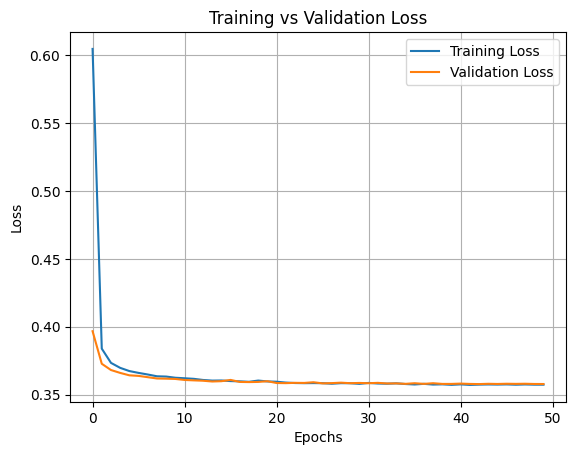

In [17]:
plt.figure()
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.grid()
plt.show()

In [18]:
model.eval()
X_tensor = X_val_tensor.to()
y_tensor = y_val_tensor.to()
y = y_val.values
with torch.no_grad():
    logits = model(X_tensor)
    y_prob = torch.softmax(logits, dim=1).cpu().numpy()
    y_pred = np.argmax(y_prob, axis=1)

In [19]:
print("Accuracy:", accuracy_score(y, y_pred))
print("Weighted F1:", f1_score(y, y_pred, average='weighted'))
print("Macro F1:", f1_score(y, y_pred, average='macro'))
print("ROC-AUC:", roc_auc_score(y, y_prob, multi_class="ovr", average="weighted"))

Accuracy: 0.8891777777777777
Weighted F1: 0.8891195390130121
Macro F1: 0.8891195390130121
ROC-AUC: 0.9715039833333335


In [20]:
print(classification_report(y, y_pred, target_names=le.classes_))

                precision    recall  f1-score   support

        BENIGN       1.00      1.00      1.00     15000
    DoS_ATTACK       0.82      0.85      0.84     15000
NON_DoS_ATTACK       0.85      0.82      0.83     15000

      accuracy                           0.89     45000
     macro avg       0.89      0.89      0.89     45000
  weighted avg       0.89      0.89      0.89     45000



In [21]:
def pgd_noise(model, X_tensor, y_tensor, epsilon, num_steps=100):
    alpha = epsilon / 10
    model.eval()
    criterion = torch.nn.CrossEntropyLoss()
    x_adv = X_tensor.clone().detach().requires_grad_(True)
    for step in range(num_steps):
        outputs = model(x_adv)
        loss = criterion(outputs, y_tensor)
        model.zero_grad()
        loss.backward()
        with torch.no_grad():
            grad_sign = x_adv.grad.sign()
            x_adv = x_adv + alpha * grad_sign
            eta = torch.clamp(x_adv - X_tensor, min=-epsilon, max=epsilon)
            x_adv = X_tensor + eta
            if 'x_min_t' in globals() and 'x_max_t' in globals():
                x_adv = torch.max(torch.min(x_adv, x_max_t), x_min_t)
        x_adv.requires_grad_(True)
    return x_adv.detach()

In [22]:
def epsilon_eval(epsilon):
    model.eval()
    X_poisoned = pgd_noise(model, X_tensor, y_tensor, epsilon)
    X_pnp = X_poisoned.cpu().numpy()
    X_inv_tr = scaler.inverse_transform(X_pnp)
    adv_df = pd.DataFrame(X_inv_tr, columns=X.columns)
    if isinstance(y_tensor, torch.Tensor):
        adv_df['true_label'] = y_tensor.cpu().numpy()
    else:
        adv_df['true_label'] = y_tensor
    with torch.no_grad():
        clean_outputs = model(X_tensor)
        poisoned_outputs = model(X_poisoned)
        clean_preds = torch.argmax(clean_outputs, dim=1)
        poisoned_preds = torch.argmax(poisoned_outputs, dim=1)
        clean_acc = (clean_preds == y_tensor).float().mean().item()
        poisoned_acc = (poisoned_preds == y_tensor).float().mean().item()
        fooling_rate = (clean_preds != poisoned_preds).float().mean().item()  
    correct_clean = (clean_preds == y_tensor)
    successful_attacks = correct_clean & (clean_preds != poisoned_preds)
    success_mask = successful_attacks.cpu().numpy()
    clean_preds_np = clean_preds.cpu().numpy()
    adv_df = adv_df[success_mask]
    adv_df["true_label"] = clean_preds_np[success_mask]
    adv_df["y_pred"] = y_pred[success_mask]
    filename = "noise_epsilon_" + str(epsilon) + ".csv"    
    adv_df.to_csv(filename, index=False)
    asr = successful_attacks.sum().item() / max(correct_clean.sum().item(), 1)
    return {
        "epsilon": epsilon,
        "clean_accuracy": clean_acc,
        "poisoned_accuracy": poisoned_acc,
        "fooling_rate": fooling_rate, 
        "asr": asr
    }

Epsilon: 0.00 | Clean Accuracy: 88.92% | Poisoned accuracy: 88.92% | Fooling rate: 0.00% | Attack Success Rate: 0.00%
Epsilon: 0.01 | Clean Accuracy: 88.92% | Poisoned accuracy: 88.79% | Fooling rate: 0.13% | Attack Success Rate: 0.14%
Epsilon: 0.05 | Clean Accuracy: 88.92% | Poisoned accuracy: 87.14% | Fooling rate: 1.78% | Attack Success Rate: 2.00%
Epsilon: 0.10 | Clean Accuracy: 88.92% | Poisoned accuracy: 84.63% | Fooling rate: 4.29% | Attack Success Rate: 4.82%
Epsilon: 0.20 | Clean Accuracy: 88.92% | Poisoned accuracy: 58.89% | Fooling rate: 30.04% | Attack Success Rate: 33.77%
Epsilon: 0.30 | Clean Accuracy: 88.92% | Poisoned accuracy: 24.95% | Fooling rate: 63.98% | Attack Success Rate: 71.94%
Epsilon: 0.40 | Clean Accuracy: 88.92% | Poisoned accuracy: 17.80% | Fooling rate: 71.13% | Attack Success Rate: 79.98%
Epsilon: 0.50 | Clean Accuracy: 88.92% | Poisoned accuracy: 15.36% | Fooling rate: 73.58% | Attack Success Rate: 82.73%


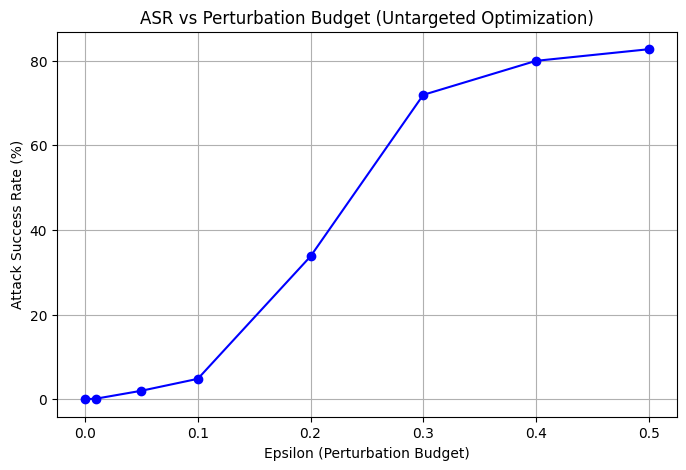

In [23]:
results = []
for epsilon in [0.0, 0.01, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5]:
    res = epsilon_eval(epsilon)
    results.append(res)
    print(f"Epsilon: {res['epsilon']:.2f} | Clean Accuracy: {res['clean_accuracy']*100:.2f}% | Poisoned accuracy: {res['poisoned_accuracy']*100:.2f}% | Fooling rate: {res['fooling_rate']*100:.2f}% | Attack Success Rate: {res['asr']*100:.2f}%")
eps = [r["epsilon"] for r in results]
asr = [r["asr"] * 100 for r in results]
plt.figure(figsize=(8,5))
plt.plot(eps, asr, marker='o', color='b', linestyle='-')
plt.xlabel("Epsilon (Perturbation Budget)")
plt.ylabel("Attack Success Rate (%)")
plt.title("ASR vs Perturbation Budget (Untargeted Optimization)")
plt.grid(True)
plt.show()